#Обучение модели экспертной системы оценки суточного рациона питания

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Загрузка эмпирического набора данных
Данные были сгенерированы на основе реальной базы USDA (файл `ABBREV_with_CLASS.csv`) путем комбинации продуктов в суточные рационы

In [12]:
dataset_path = "ration_dataset.csv"
if not os.path.exists(dataset_path):
    print("датасет не найден")
else:
    df = pd.read_csv(dataset_path)
    display(df.head())
    print(f"Размер датасета {df.shape}")

,calories,protein,fat,carbs,label
0,2439.850274,113.104756,141.216201,173.068183,Избыток жиров
1,2522.449595,240.684236,42.663493,296.995711,Дисбаланс нутриентов
2,2700.407772,165.436624,72.402230,353.456532,Избыток калорий
3,3609.212550,232.880942,250.956376,112.920553,Избыток калорий
4,4613.143495,339.960724,208.301439,337.580025,Избыток калорий


Размер датасета (10000, 5)


## 2. Анализ датасета (EDA)

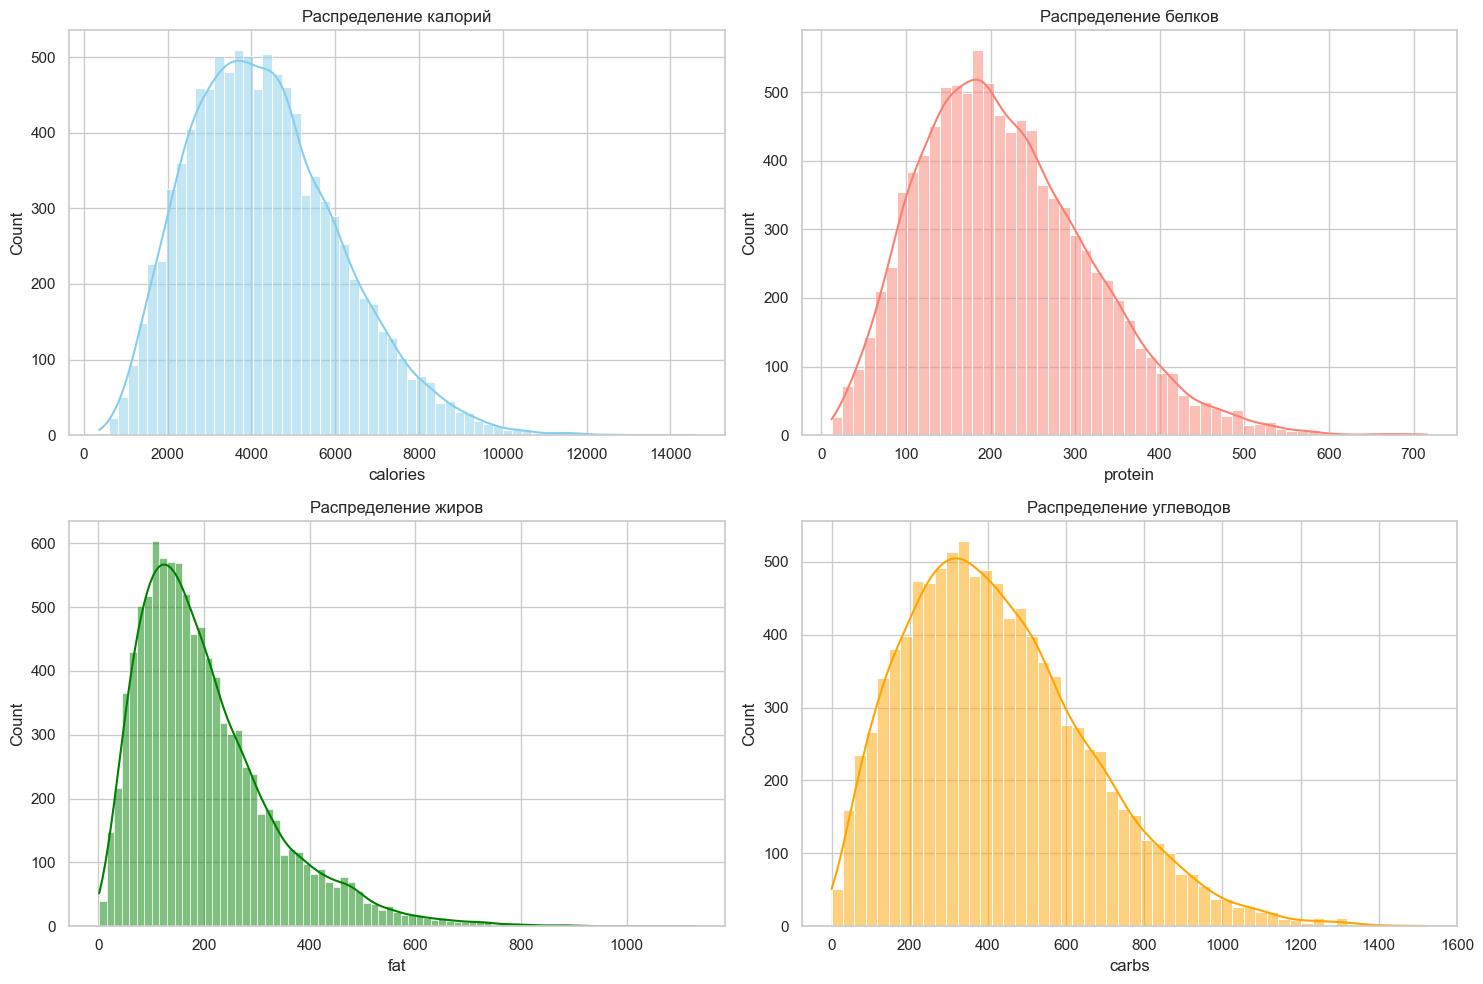

In [13]:
# распределение калорий и макронутриентов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['calories'], kde=True, ax=axes[0, 0], color='skyblue').set_title('Распределение калорий')
sns.histplot(df['protein'], kde=True, ax=axes[0, 1], color='salmon').set_title('Распределение белков')
sns.histplot(df['fat'], kde=True, ax=axes[1, 0], color='green').set_title('Распределение жиров')
sns.histplot(df['carbs'], kde=True, ax=axes[1, 1], color='orange').set_title('Распределение углеводов')

plt.tight_layout()
plt.show()

/var/folders/qx/8qd5d2fd3y9f2rt8fxdmn2100000gn/T/ipykernel_39853/1221781556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, palette='viridis')


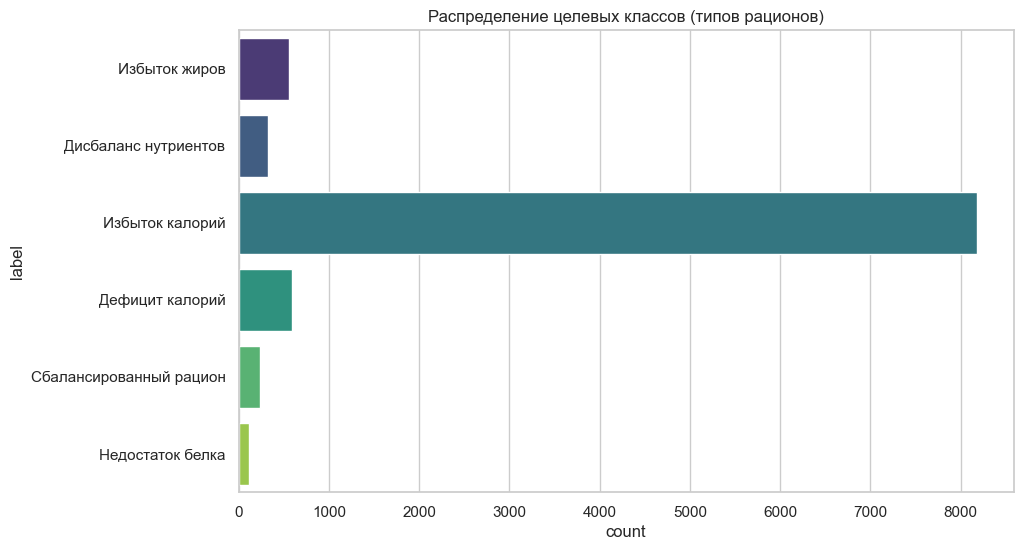

In [14]:
# баланс классов
plt.figure(figsize=(10, 6))
sns.countplot(y='label', data=df, palette='viridis')
plt.title('Распределение целевых классов (типов рационов)')
plt.show()

## 3. Подготовка данных к обучению

In [15]:
X = df.drop('label', axis=1)
y = df['label']

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (8000, 4)
Тестовая выборка: (2000, 4)


## 4. Сравнение моделей машинного обучения

In [16]:
model_candidates = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "LinearSVM": SVC(kernel='linear', C=1.0, probability=True, random_state=42)
}

results = {}
for name, model in model_candidates.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nЛучшая модель - {best_model_name}")

RandomForest: Accuracy = 0.9120
GradientBoosting: Accuracy = 0.9145
LinearSVM: Accuracy = 0.9115

Лучшая модель - GradientBoosting


## 5. Оценка финальной модели

                         precision    recall  f1-score   support

        Дефицит калорий       0.85      0.82      0.83       117
   Дисбаланс нутриентов       0.64      0.54      0.58        65
          Избыток жиров       0.70      0.52      0.60       111
        Избыток калорий       0.95      0.98      0.96      1636
       Недостаток белка       0.52      0.61      0.56        23
Сбалансированный рацион       0.72      0.44      0.55        48

               accuracy                           0.91      2000
              macro avg       0.73      0.65      0.68      2000
           weighted avg       0.91      0.91      0.91      2000



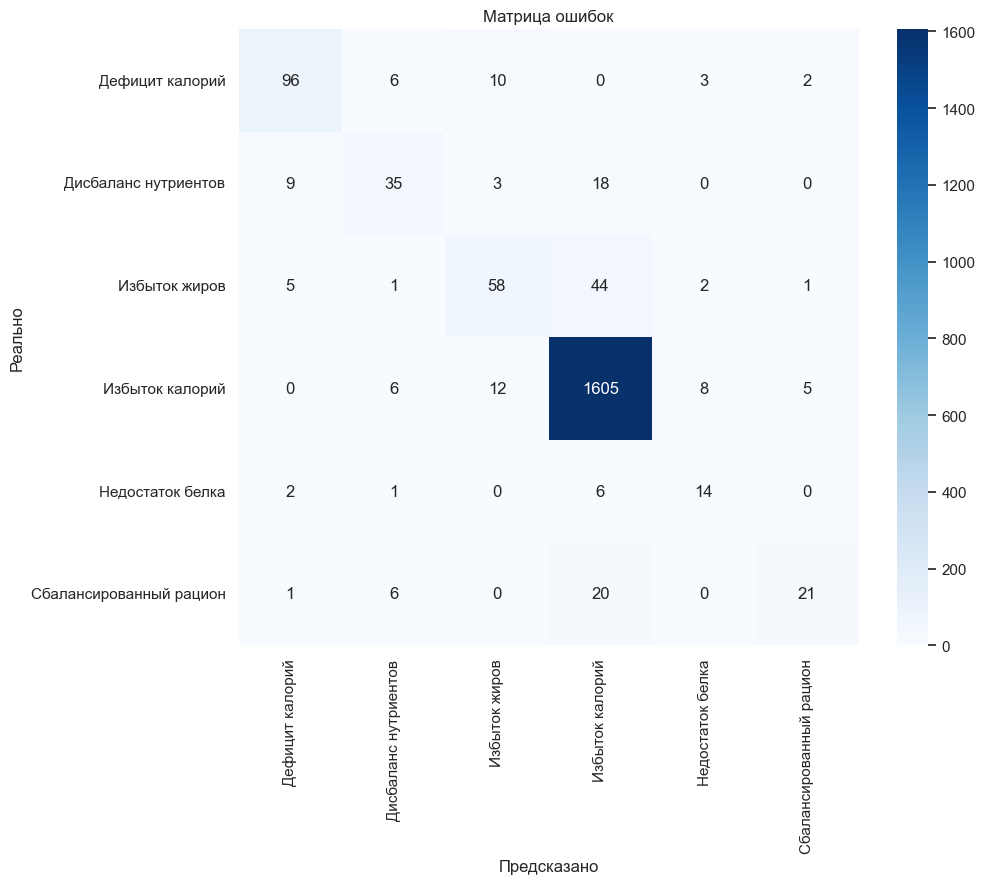

In [17]:
best_model = model_candidates[best_model_name]
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

# визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.show()

## 6. Анализ важности признаков

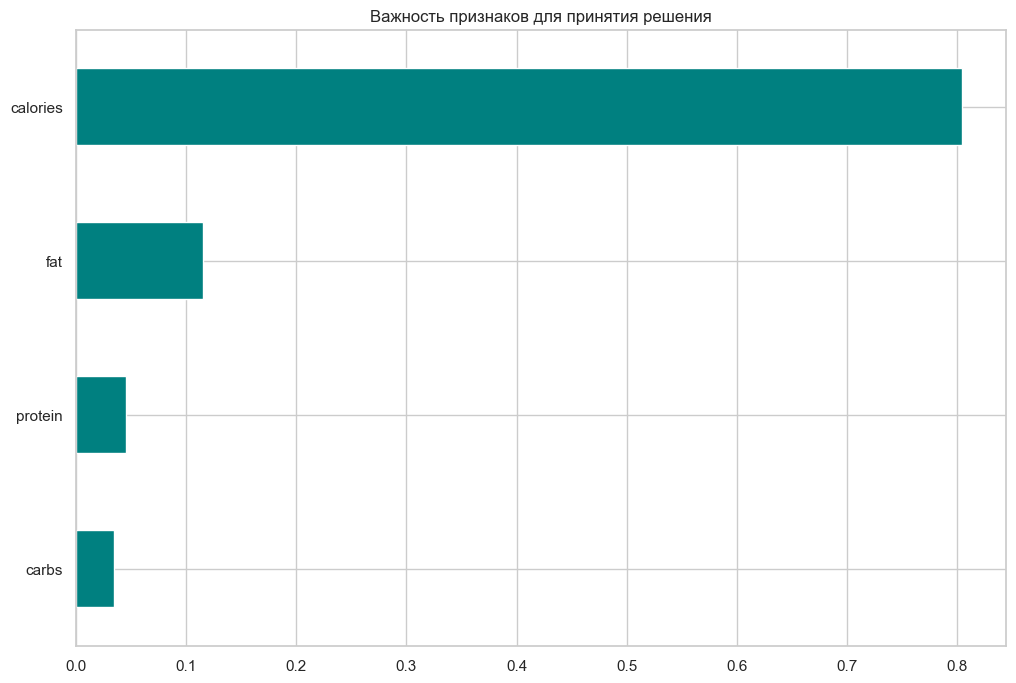

In [18]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', color='teal')
    plt.title('Важность признаков для принятия решения')
    plt.show()

In [19]:
# сохранение модели
joblib.dump(best_model, 'model.joblib')
print("Модель сохранена в model.joblib")

Модель сохранена в model.joblib
